In [9]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

In [10]:
def count_stats(qc):
    qc.measure_all()

    simulator = AerSimulator()
    result = simulator.run(qc, shots=1000).result()
    counts = result.get_counts()
 
    return counts

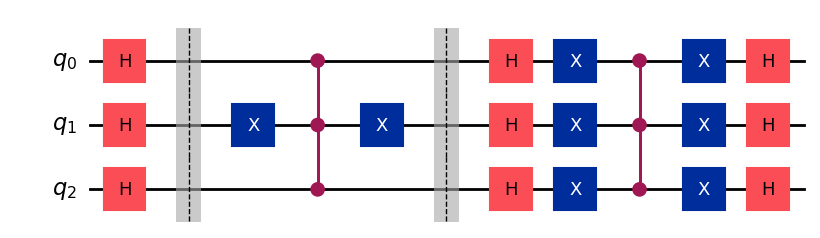

In [11]:
qc = QuantumCircuit(3)

qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

qc.x(1)
qc.ccz(0, 1, 2)
qc.x(1)
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.ccz(0, 1, 2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)

qc.draw('mpl')

In [12]:
count_stats(qc)

{'100': 28,
 '111': 28,
 '011': 38,
 '010': 31,
 '000': 35,
 '001': 30,
 '110': 24,
 '101': 786}

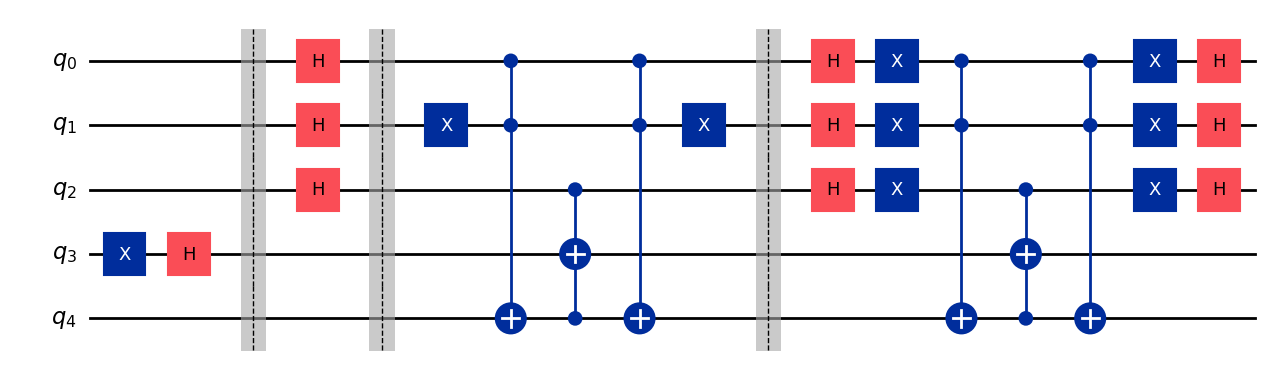

In [ ]:
qc = QuantumCircuit( # 3 кубита для поиска Гровером,
    5                # 4-й кубит вспом. для Гровера,
)                    # 5-й кубит вспом. для CCCX

# Образуем на вспом. состояние (|0> - |1>) / √2
qc.x(3)
qc.h(3)
qc.barrier()

# Создаём суперпозицию из всех возможных вариантов
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# ОРАКУЛ -- помечает искомое сост. знаком МИНУС
qc.x(1)
qc.ccx(0, 1, 4)
qc.ccx(2, 4, 3)
qc.ccx(0, 1, 4)
qc.x(1)
qc.barrier()

# ИНВЕРСИЯ ОТНОСИТЕЛЬНО СРЕДНЕГО (кроме вспом.)
qc.h(0)
qc.h(1)
qc.h(2)
qc.x(0)
qc.x(1)
qc.x(2)
qc.ccx(0, 1, 4)
qc.ccx(2, 4, 3)
qc.ccx(0, 1, 4)
qc.x(0)
qc.x(1)
qc.x(2)
qc.h(0)
qc.h(1)
qc.h(2)

qc.draw('mpl')

In [18]:
count_stats(qc)

{'00001': 11,
 '01100': 21,
 '01110': 17,
 '01011': 22,
 '00011': 17,
 '00111': 14,
 '01111': 10,
 '01101': 408,
 '00000': 8,
 '00010': 8,
 '00101': 386,
 '01001': 15,
 '00110': 12,
 '01000': 19,
 '01010': 15,
 '00100': 17}